# Experimento 8 — Dos niveles con un combinador lineal (regresión logística + interacciones)

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento7.ipynb`. La sección 1 repite de forma resumida la configuración común (misma
semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a ejecutar**: sus métricas se
registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 8 — Combinador lineal con interacciones

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de los experimentos 2 a 7 tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "acc_cv": 0.8865, "std_cv": 0.0099, "acc_test": 0.8992, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector, LinearSVC",
     "acc_cv": 0.9009, "std_cv": 0.0057, "acc_test": 0.8975, "envio": "submission_04.csv", "kaggle_publico": None},
    {"experimento": 5, "descripcion": "Como el exp. 4, con el detector aplicado a la oración sin su conector inicial",
     "acc_cv": 0.9022, "std_cv": 0.0080, "acc_test": 0.9021, "envio": "submission_05.csv", "kaggle_publico": None},
    {"experimento": 6, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> HistGradientBoosting",
     "acc_cv": 0.9039, "std_cv": 0.0102, "acc_test": 0.9150, "envio": "submission_06.csv", "kaggle_publico": 0.90},
    {"experimento": 7, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1)",
     "acc_cv": 0.9071, "std_cv": 0.0091, "acc_test": 0.9046, "envio": "submission_07.csv", "kaggle_publico": 0.91},
]:
    resultados.append(fila)

# Accuracy por fold del experimento 7 (mismos folds; experimento7.ipynb, sección 2.4, SVM RBF C=1 gamma=scale)
ACC_FOLDS_E7 = np.array([0.9130, 0.9010, 0.9161, 0.9130, 0.8922])

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 6", "escenario": "Original", "accuracy": 0.9150},
    {"modelo": "Exp. 6", "escenario": "Oraciones desordenadas", "accuracy": 0.7354},
    {"modelo": "Exp. 6", "escenario": "Última oración al inicio", "accuracy": 0.5921},
    {"modelo": "Exp. 7", "escenario": "Original", "accuracy": 0.9046},
    {"modelo": "Exp. 7", "escenario": "Oraciones desordenadas", "accuracy": 0.7458},
    {"modelo": "Exp. 7", "escenario": "Última oración al inicio", "accuracy": 0.6008},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",NaN,NaN,0.8865,0.0099,NaN,0.8992,NaN,submission_02.csv,0.88
2,4,"Texto completo + última oración con opinión (detector) + tras conector, LinearSVC",NaN,NaN,0.9009,0.0057,NaN,0.8975,NaN,submission_04.csv,NaN
3,5,"Como el exp. 4, con el detector aplicado a la oración sin su conector inicial",NaN,NaN,0.9022,0.0080,NaN,0.9021,NaN,submission_05.csv,NaN
4,6,Dos niveles: LinearSVC + polaridad por oración -> HistGradientBoosting,NaN,NaN,0.9039,0.0102,NaN,0.9150,NaN,submission_06.csv,0.90
5,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91


## 2. Experimento 8 — Combinador lineal con interacciones

**Motivación:** el experimento 7 obtuvo **0,91 en el leaderboard público**, el mejor score del grupo, con un
combinador **SVM con kernel RBF**. Ese kernel es difícil de sustentar: decide comparando cada reseña con cientos de
reseñas de entrenamiento (vectores de soporte) mediante una función de similitud, y su frontera no se puede leer
directamente.

**Objetivo:** reemplazar el combinador por un modelo **lineal e interpretable** sin perder accuracy.

**Por qué una regresión logística simple no basta (experimento 7):** obtuvo 0,9022, medio punto menos que el SVM RBF,
porque solo **suma** features y la ganancia del segundo nivel está en **interacciones** como *"la polaridad de la
última opinión pesa distinto si empieza con un conector secundario"*.

**Idea:** darle esas interacciones a la regresión logística de forma explícita. Antes del modelo se agregan como
features nuevas **todos los productos entre pares de features** (`PolynomialFeatures(degree=2)`). Por ejemplo, el
producto `pol_ultima × ultima_secundario` vale la polaridad de la última opinión solo cuando esa opinión empieza con
`de paso`, `por cierto`, `por otro lado` o `ademas`, y 0 en otro caso. Su coeficiente indica cuánto cambia el peso
de la última opinión en esa situación. El modelo sigue siendo **una regresión logística**: lineal en sus features,
con coeficientes que se pueden leer. Como las features crecen de 17 a ≈ 170, se usa **regularización L2 fuerte** y
se ajusta `C` con CV.

**Todo lo demás es idéntico al experimento 7:** normalización, detector de opinión, TF-IDF por partes, LinearSVC
como modelo base, modelo de polaridad por oración, features de estructura y cross-fitting.

### 2.1 Definiciones

Las mismas funciones y el mismo transformador `PartesE5` de `experimento5.ipynb` (sección 2.1).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Nivel 1 y caché de features (igual que el experimento 7)

Misma celda de la sección 2.2 de `experimento7.ipynb`: entrena el nivel 1 y calcula, para cada fold, las features
de nivel 2 con cross-fitting. Tarda ≈ 15 minutos. Permite comparar combinadores sobre exactamente las mismas
features y folds.

In [7]:
import time

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier,
                              VotingClassifier)
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def fit_nivel1(X, y):
    """Detector + TF-IDF por partes compartidos; tres modelos base y un modelo de polaridad de oraciones."""
    partes = PartesE5(quitar=True).fit(X, y)
    D = partes.transform(X)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    M = tfidf.transform(D)
    bases = {
        "svc": LinearSVC(C=0.2, max_iter=5000, random_state=SEED).fit(M, y),
        "lr": LogisticRegression(C=1, max_iter=4000, random_state=SEED).fit(M, y),
        "cnb": ComplementNB(alpha=0.3).fit(M, y),
    }
    y = np.asarray(y)
    es_np = y != "neutral"
    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, m in zip(X, es_np) if m]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[es_np])
    return partes, tfidf, bases, polaridad


def features_nivel1(X, nivel1):
    """Features de nivel 2 por bloques: puntajes de cada modelo base + 14 features estructurales."""
    partes, tfidf, bases, polaridad = nivel1
    M = tfidf.transform(partes.transform(X))
    bloques = {
        "svc": bases["svc"].decision_function(M),
        "lr": bases["lr"].predict_log_proba(M),
        "cnb": bases["cnb"].predict_log_proba(M),
    }
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    bloques["estructura"] = np.array(estructura)
    return bloques


def features_cross_fitting(X, y, k=5):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X = pd.Series(list(X))
    y = np.asarray(y)
    F = None
    for idx_tr, idx_va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y):
        bloques = features_nivel1(X.iloc[idx_va], fit_nivel1(X.iloc[idx_tr], y[idx_tr]))
        if F is None:
            F = {b: np.zeros((len(X), v.shape[1])) for b, v in bloques.items()}
        for b, v in bloques.items():
            F[b][idx_va] = v
    return F


def matriz(bloques, bases):
    return np.hstack([bloques[b] for b in bases + ["estructura"]])


def _fold_externo(idx_tr, idx_va):
    X_tr, y_tr = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    F_tr = features_cross_fitting(X_tr, y_tr)
    F_va = features_nivel1(pd.Series(list(X_train.iloc[idx_va])), fit_nivel1(pd.Series(list(X_tr)), y_tr.to_numpy()))
    return F_tr, F_va, y_tr.to_numpy(), y_train.iloc[idx_va].to_numpy()


inicio = time.time()
CACHE = Parallel(n_jobs=5)(delayed(_fold_externo)(tr, va) for tr, va in skf.split(X_train, y_train))
print(f"Features de nivel 2 calculadas para los 5 folds en {(time.time() - inicio) / 60:.1f} min")
print("Bloques:", {b: v.shape[1] for b, v in CACHE[0][0].items()})

Features de nivel 2 calculadas para los 5 folds en 1.6 min
Bloques: {'svc': 3, 'lr': 3, 'cnb': 3, 'estructura': 14}


### 2.3 Combinadores lineales

Se comparan, con LinearSVC como modelo base y las mismas features del experimento 7:
- regresión logística simple (sin interacciones), como referencia;
- regresión logística con **interacciones de grado 2** y distintos valores de `C`.

Todas llevan `StandardScaler` (las features tienen escalas distintas), y la versión con interacciones lleva un
segundo `StandardScaler` después de crear los productos. La fila del experimento 7 (SVM RBF) se toma de su notebook.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

NOMBRES_FEATURES = (["svc_negativo", "svc_neutral", "svc_positivo",
                     "pol_antepenultima", "pol_penultima", "pol_ultima",
                     "n_opiniones", "termina_evasiva", "ultimas_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])


def evaluar_cache(fabrica, bases):
    """Accuracy por fold de un combinador entrenado y evaluado sobre las features en caché."""
    accs = []
    for F_tr, F_va, y_tr, y_va in CACHE:
        modelo = fabrica().fit(matriz(F_tr, bases), y_tr)
        accs.append(accuracy_score(y_va, modelo.predict(matriz(F_va, bases))))
    return np.array(accs)


def lr_simple(C=1):
    return Pipeline([("escala", StandardScaler()),
                     ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED))])


def lr_interacciones(C):
    return Pipeline([
        ("escala", StandardScaler()),
        ("interacciones", PolynomialFeatures(degree=2, include_bias=False)),
        ("escala2", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED)),
    ])


COMBINADORES = {"LR simple (C = 1)": lambda: lr_simple(1)}
for C in [0.003, 0.01, 0.03, 0.1, 0.3]:
    COMBINADORES[f"LR + interacciones (C = {C})"] = (lambda C=C: lr_interacciones(C))

acc_comb = {"[ref. exp. 7] SVM RBF": ACC_FOLDS_E7}
for nombre, fabrica in COMBINADORES.items():
    acc_comb[nombre] = evaluar_cache(fabrica, ["svc"])

comparacion = pd.DataFrame({
    "acc_cv": {k: v.mean() for k, v in acc_comb.items()},
    "std": {k: v.std() for k, v in acc_comb.items()},
    "diferencia con exp. 7": {k: v.mean() - ACC_FOLDS_E7.mean() for k, v in acc_comb.items()},
    "folds que gana al exp. 7": {k: int((v > ACC_FOLDS_E7).sum()) for k, v in acc_comb.items()},
}).round(4).sort_values("acc_cv", ascending=False)
comparacion

,acc_cv,std,diferencia con exp. 7,folds que gana al exp. 7
[ref. exp. 7] SVM RBF,0.9071,0.0091,0.0000,0
LR + interacciones (C = 0.03),0.9048,0.0083,-0.0023,2
LR + interacciones (C = 0.01),0.9047,0.0095,-0.0024,3
LR + interacciones (C = 0.003),0.9045,0.0089,-0.0026,1
LR + interacciones (C = 0.1),0.9041,0.0082,-0.0030,0
LR + interacciones (C = 0.3),0.9039,0.0077,-0.0032,0
LR simple (C = 1),0.9022,0.0051,-0.0049,1


In [9]:
pd.DataFrame(acc_comb, index=[f"fold {k}" for k in range(1, 6)]).T.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5
[ref. exp. 7] SVM RBF,0.9130,0.9010,0.9161,0.9130,0.8922
LR simple (C = 1),0.9021,0.9005,0.9083,0.9062,0.8938
LR + interacciones (C = 0.003),0.9057,0.8979,0.9146,0.9130,0.8911
LR + interacciones (C = 0.01),0.9042,0.8958,0.9167,0.9141,0.8927
LR + interacciones (C = 0.03),0.9042,0.8990,0.9167,0.9109,0.8932
LR + interacciones (C = 0.1),0.9057,0.9000,0.9141,0.9099,0.8906
LR + interacciones (C = 0.3),0.9062,0.9005,0.9115,0.9104,0.8906


**Lectura**

- **Las interacciones recuperan la mayor parte de la diferencia:** la regresión logística simple queda 0,49
  puntos por debajo del SVM RBF; con interacciones de grado 2 la diferencia baja a **0,23 puntos** (0,9048 con
  `C = 0,03`), menos que la desviación entre folds (≈ 0,008). Gana o empata al SVM RBF en 2 de 5 folds. En la
  práctica, **los dos combinadores rinden igual**.
- El resultado es estable frente a `C`: entre 0,003 y 0,3 queda en 0,9039–0,9048. Con ≈ 170 features (17 originales
  + 136 productos + 17 cuadrados), la regularización fuerte (`C` pequeño) evita que el modelo se ajuste a
  combinaciones raras.
- Esto confirma lo visto en el experimento 7: la ventaja del SVM RBF no venía de ser un SVM, sino de poder combinar
  features de forma **no lineal**. Una regresión logística con las interacciones explícitas consigue casi lo mismo.

### 2.4 Modelo del experimento 8

Se usa la regresión logística con interacciones con el mejor `C` de la tabla anterior. La clase `DosNivelesV2`
(igual a la del experimento 7) reproduce el procedimiento evaluado en la caché: cross-fitting en `fit` y nivel 1
reentrenado con todos los datos de entrenamiento para predecir.

In [10]:
class DosNivelesV2(BaseEstimator, ClassifierMixin):
    """Stacking del exp. 6/7 con modelos base y combinador configurables."""

    def __init__(self, bases=("svc",), nivel2=None):
        self.bases = bases
        self.nivel2 = nivel2

    def fit(self, X, y):
        X = pd.Series(list(X))
        y = np.asarray(y)
        F = features_cross_fitting(X, y)
        self.nivel1_ = fit_nivel1(X, y)
        self.nivel2_ = clone(self.nivel2).fit(matriz(F, list(self.bases)), y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        X = pd.Series(list(X))
        return self.nivel2_.predict(matriz(features_nivel1(X, self.nivel1_), list(self.bases)))


candidatos_inter = {k: v for k, v in acc_comb.items() if k.startswith("LR + interacciones")}
mejor_nombre = max(candidatos_inter, key=lambda k: candidatos_inter[k].mean())
C_E8 = float(mejor_nombre.split("C = ")[1].rstrip(")"))
acc_final = candidatos_inter[mejor_nombre]
print(f"Combinador elegido: {mejor_nombre} | CV = {acc_final.mean():.4f} ± {acc_final.std():.4f}")

modelo_e8 = DosNivelesV2(bases=("svc",), nivel2=lr_interacciones(C_E8)).fit(X_train, y_train)
print(f"Accuracy de entrenamiento: {accuracy_score(y_train, modelo_e8.predict(X_train)):.4f}")

Combinador elegido: LR + interacciones (C = 0.03) | CV = 0.9048 ± 0.0083


Accuracy de entrenamiento: 0.9279


Test -> accuracy: 0.9096 | F1 macro: 0.9140

              precision    recall  f1-score   support

    negativo      0.869     0.879     0.874       843
     neutral      0.997     0.994     0.996       715
    positivo      0.876     0.868     0.872       842

    accuracy                          0.910      2400
   macro avg      0.914     0.914     0.914      2400
weighted avg      0.910     0.910     0.910      2400



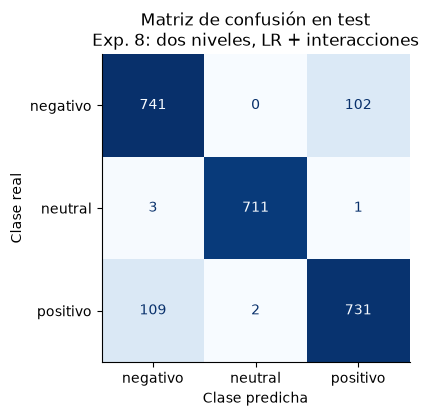

Negativo vs positivo en test: 0.874 (exp. 7: 0,865)


In [11]:
metricas_e8 = evaluar_en_test(modelo_e8, "Exp. 8: dos niveles, LR + interacciones")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e8['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f}"
      " (exp. 7: 0,865)")

### 2.5 ¿Qué aprendió el combinador? (interpretación)

A diferencia del SVM RBF, la regresión logística permite leer qué combinaciones de features usa. Se muestran las
features e interacciones con mayor coeficiente (en valor absoluto) para `positivo` y `negativo`. Como las features
están estandarizadas, los coeficientes son comparables entre sí. Un nombre como `pol_ultima ultima_secundario` es el
producto de esas dos features.

In [12]:
comb = modelo_e8.nivel2_
nombres_inter = comb.named_steps["interacciones"].get_feature_names_out(NOMBRES_FEATURES)
coef = pd.DataFrame(comb.named_steps["clf"].coef_.T, index=nombres_inter, columns=comb.named_steps["clf"].classes_)
coef["solo_interaccion"] = [" " in n for n in coef.index]

for clase in ["positivo", "negativo"]:
    top = coef[clase].abs().sort_values(ascending=False).head(12).index
    print(f"=== {clase}: 12 coeficientes de mayor magnitud ===")
    print(coef.loc[top, [clase]].round(3).to_string())
    print()

print(f"Coeficientes totales: {len(coef)} | de interacción: {coef['solo_interaccion'].sum()}")

=== positivo: 12 coeficientes de mayor magnitud ===
                              positivo
svc_positivo                     0.819
svc_positivo n_opiniones        -0.439
svc_negativo                    -0.435
pol_ultima                       0.385
svc_neutral                     -0.291
svc_neutral ultimas_opuestas     0.273
svc_neutral n_opiniones          0.226
ultimas_opuestas^2               0.188
ultimas_opuestas                 0.188
svc_negativo svc_neutral         0.186
n_opiniones                      0.183
svc_positivo termina_evasiva    -0.183

=== negativo: 12 coeficientes de mayor magnitud ===
                               negativo
svc_negativo                      0.849
pol_ultima                       -0.438
svc_negativo n_opiniones         -0.399
svc_positivo                     -0.377
svc_neutral                      -0.363
svc_neutral svc_positivo          0.318
svc_neutral^2                    -0.244
svc_neutral n_opiniones           0.214
n_opiniones                 

**Lectura**

- **Los puntajes del LinearSVC siguen siendo la base de la decisión** (`svc_positivo` y `svc_negativo` son los
  coeficientes más grandes): el combinador parte de lo que dice el modelo de texto.
- **La polaridad de la última opinión aporta información propia** (`pol_ultima`: +0,39 para `positivo`, −0,44 para
  `negativo`).
- **Las interacciones de mayor peso ajustan cuánto confiar en el LinearSVC según la situación de la reseña:**
  - `svc_positivo × n_opiniones` (−0,44) y `svc_negativo × n_opiniones` (−0,40): cuantas **más opiniones**
    contiene la reseña, **menos se confía** en el puntaje del LinearSVC (hay más elogios y quejas mezclados);
  - `svc_positivo × termina_evasiva` (−0,18): si la reseña termina en una **evasiva**, se confía menos en un puntaje
    positivo;
  - `svc_neutral × ultimas_opuestas` (+0,27) y `svc_negativo × ultimas_opuestas` (−0,19): cuando las dos últimas
    opiniones se **contradicen**, cambia cómo se combinan los puntajes.
- Las interacciones con el **tipo de conector** (`ultima_secundario`...) no aparecen entre las de mayor peso: su
  efecto está repartido en varios coeficientes pequeños, coherente con que en esos grupos la etiqueta es casi
  aleatoria (experimento 5).
- En resumen, el combinador aprende reglas legibles del tipo *"el LinearSVC es menos confiable en reseñas con
  muchas opiniones, opiniones contradictorias o final evasivo"*. Es la misma clase de corrección que hacía el SVM
  RBF, pero ahora se puede leer en los coeficientes.

### 2.6 Prueba de robustez en test

In [13]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 8", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e8.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 6,Exp. 7,Exp. 8
escenario,,,
Original,0.9150,0.9046,0.9096
Oraciones desordenadas,0.7354,0.7458,0.7621
Última oración al inicio,0.5921,0.6008,0.6467


### 2.7 Registro y envío

In [14]:
from types import SimpleNamespace

resultados.append({
    "experimento": 8,
    "descripcion": f"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C={C_E8})",
    "acc_cv": round(acc_final.mean(), 4),
    "std_cv": round(acc_final.std(), 4),
    "acc_test": round(metricas_e8["acc_test"], 4),
    "envio": "submission_08.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",NaN,NaN,0.8865,0.0099,NaN,0.8992,NaN,submission_02.csv,0.88
2,4,"Texto completo + última oración con opinión (detector) + tras conector, LinearSVC",NaN,NaN,0.9009,0.0057,NaN,0.8975,NaN,submission_04.csv,NaN
3,5,"Como el exp. 4, con el detector aplicado a la oración sin su conector inicial",NaN,NaN,0.9022,0.0080,NaN,0.9021,NaN,submission_05.csv,NaN
4,6,Dos niveles: LinearSVC + polaridad por oración -> HistGradientBoosting,NaN,NaN,0.9039,0.0102,NaN,0.9150,NaN,submission_06.csv,0.90
5,7,Dos niveles: LinearSVC + polaridad por oración -> SVM RBF (C=1),NaN,NaN,0.9071,0.0091,NaN,0.9046,NaN,submission_07.csv,0.91
6,8,Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0.03),NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN


In [15]:
envio_e8 = generar_envio(SimpleNamespace(best_estimator_=modelo_e8), numero=8)

Envío guardado en envios/submission_08.csv y modelo en modelos/modelo_08.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.7
neutral     27.6
positivo    36.8


### 2.8 Análisis del experimento 8

**Resultados:** accuracy de CV = **0,9048 ± 0,0083** y accuracy en test = **0,9096**.

| | Exp. 5 | Exp. 6 | Exp. 7 | Exp. 8 |
|---|---|---|---|---|
| Combinador | — (un solo nivel) | HGB | SVM RBF | **LR + interacciones** |
| Accuracy CV | 0,9022 | 0,9039 | **0,9071** | 0,9048 |
| Accuracy de entrenamiento | 0,9773 | 0,9392 | 0,9370 | **0,9279** |
| Accuracy test | 0,9021 | **0,9150** | 0,9046 | 0,9096 |
| Kaggle público | — | 0,90 | **0,91** | pendiente |
| Test, oraciones desordenadas | 0,738 | 0,735 | 0,746 | **0,762** |
| Test, última oración al inicio | 0,595 | 0,592 | 0,601 | **0,647** |

1. **Empate técnico con el experimento 7:** −0,23 puntos en CV (dentro del ruido) y +0,50 en test. Ninguna de las
   dos diferencias es concluyente.
2. **Es el combinador más fácil de sustentar:** todo el modelo usa solo modelos lineales vistos en el curso
   (regresión logística, SVM lineal) más interacciones explícitas, y sus coeficientes se pueden interpretar
   (sección 2.5).
3. **Es el que menos sobreajusta** (train 0,928) y el **más robusto** de los modelos de dos niveles cuando el
   veredicto no está al final (0,647 frente a 0,601 del experimento 7 con la última oración al inicio). Sigue
   dependiendo de la posición, como todos los modelos basados en el experimento 2.
4. **Costo:** igual que el experimento 7 (cuatro modelos y cross-fitting).

**Decisión:** el experimento 8 es una alternativa **equivalente en accuracy y más fácil de sustentar** que el
experimento 7. Se genera `submission_08.csv`. Si su score público queda en ≈ 0,91, conviene usarlo como modelo
final de la entrega; si queda claramente por debajo, se mantiene el experimento 7 (mejor score público).